# Customer Segmentation Analysis
## Oasis Infobyte — Data Analytics Internship
### Name: Priti Ranjit | Track: Data Analytics | Task: L1 Task 2

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("All libraries imported successfully!")

All libraries imported successfully!


In [14]:
df = pd.read_csv('Mall_Customers.csv')

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Step 1: Data Inspection & Cleaning

In [15]:
print("Column names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Column names: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types:
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


## Step 2: Descriptive Statistics

In [16]:
print("Average Annual Income:", df['Annual Income (k$)'].mean())
print("Average Spending Score:", df['Spending Score (1-100)'].mean())
print("Average Age:", df['Age'].mean())

df.describe()

Average Annual Income: 60.56
Average Spending Score: 50.2
Average Age: 38.85


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Step 3: Feature Selection for Clustering
We will use Annual Income and Spending Score — 
the two most relevant behavioral features for segmentation.

In [17]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
print("Selected features for clustering:")
X.head()

Selected features for clustering:


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Step 4: Standardize the Data

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data standardized successfully!")
print(X_scaled[:5])

Data standardized successfully!
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


## Step 5: Elbow Method to Find Optimal K

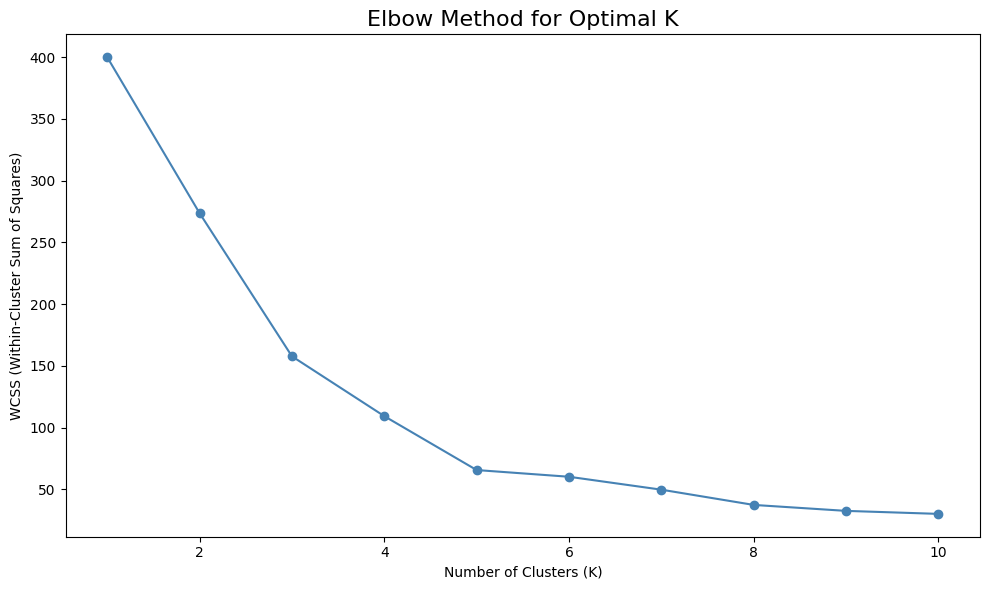

In [19]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', color='steelblue')
plt.title('Elbow Method for Optimal K', fontsize=16)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.tight_layout()
plt.savefig('elbow_method.png')
plt.show()

## Step 6: Apply K-Means Clustering
Based on the elbow curve, K=5 appears optimal.

In [20]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Clustering complete!")
df.head()

Clustering complete!


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Step 7: Visualize the Clusters

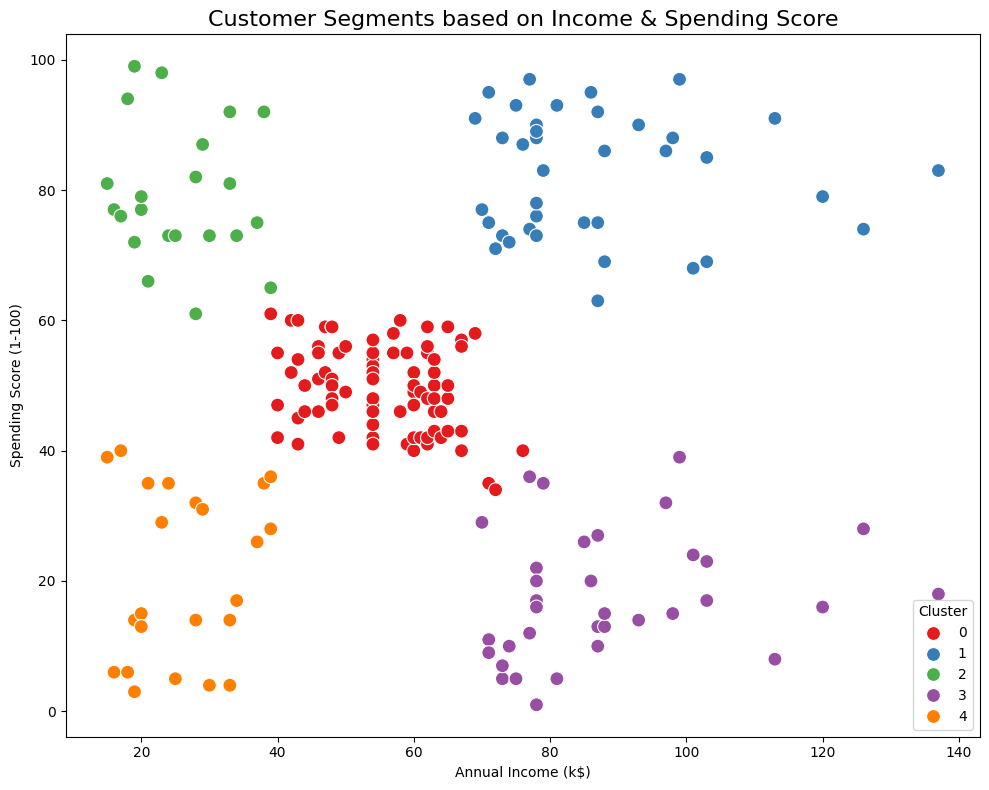

In [21]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Annual Income (k$)', 
                 y='Spending Score (1-100)', 
                 hue='Cluster', palette='Set1', s=100)
plt.title('Customer Segments based on Income & Spending Score', fontsize=16)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('customer_clusters.png')
plt.show()

## Step 8: Cluster Profiling

In [22]:
cluster_profile = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean()

print("Cluster Profiles (Average Values):")
print(cluster_profile)


Cluster Profiles (Average Values):
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


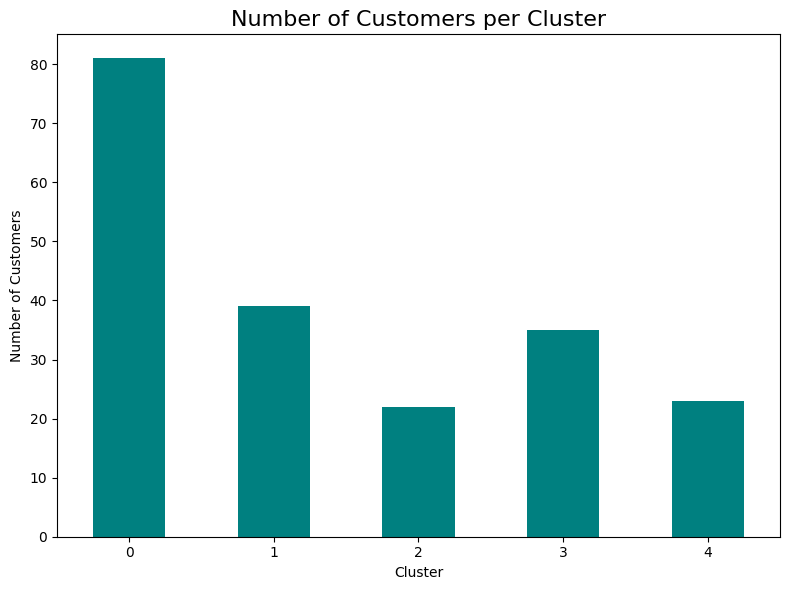

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [23]:
plt.figure(figsize=(8, 6))
df['Cluster'].value_counts().sort_index().plot(kind='bar', color='teal')
plt.title('Number of Customers per Cluster', fontsize=16)
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cluster_counts.png')
plt.show()

print(df['Cluster'].value_counts().sort_index())

## Step 9: Marketing Insights & Recommendations

In [24]:
print("CLUSTER INSIGHTS & MARKETING RECOMMENDATIONS")
print("="*60)

print("""
Cluster 0 - Low Income, Low Spending:
  → Budget-conscious customers. Target with discounts and 
    value deals.

Cluster 1 - High Income, Low Spending:
  → High potential but not engaged. Target with premium 
    loyalty programs to increase engagement.

Cluster 2 - Low Income, High Spending:
  → Impulsive buyers despite low income. Target with 
    installment payment options.

Cluster 3 - High Income, High Spending:
  → Best customers! Target with VIP programs and 
    exclusive early access to new products.

Cluster 4 - Average Income, Average Spending:
  → Stable mainstream customers. Target with regular 
    seasonal promotions.
""")

CLUSTER INSIGHTS & MARKETING RECOMMENDATIONS

Cluster 0 - Low Income, Low Spending:
  → Budget-conscious customers. Target with discounts and 
    value deals.

Cluster 1 - High Income, Low Spending:
  → High potential but not engaged. Target with premium 
    loyalty programs to increase engagement.

Cluster 2 - Low Income, High Spending:
  → Impulsive buyers despite low income. Target with 
    installment payment options.

Cluster 3 - High Income, High Spending:
  → Best customers! Target with VIP programs and 
    exclusive early access to new products.

Cluster 4 - Average Income, Average Spending:
  → Stable mainstream customers. Target with regular 
    seasonal promotions.



## Conclusion

### Key Findings:
1. Using the Elbow Method, 5 was identified as the optimal 
   number of customer clusters
2. Customers were successfully segmented based on Annual 
   Income and Spending Score
3. Each cluster represents a distinct customer behavior 
   pattern requiring different marketing strategies

### Business Recommendations:
1. **High Income, High Spending customers** should receive 
   VIP treatment and exclusive offers — they are the most 
   valuable segment
2. **High Income, Low Spending customers** represent untapped 
   potential — targeted engagement campaigns could increase 
   their spending
3. **Low Income, High Spending customers** may benefit from 
   flexible payment options to maintain their purchasing 
   behavior without financial strain